# DATA PROFILING

In this notebook, we'll try to understand our data. We'll sift through the data to understand its size, unique features, how they are distibuted and any data quality issues our data might have.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## 🧠 Analyst Note: Profiling Approach
**Why we start here:** Before touching any data, we need to understand its shape, completeness, and internal consistency. This dataset represents a *customer snapshot* — each row is one customer, not one transaction. That distinction matters: we cannot compute recency or frequency from raw timestamps (there are none). All behavioural signals must be inferred from proxy fields like  and .

**What we are looking for in profiling:**
- Row/column counts and data types
- Null values and their distribution
- Duplicate records
- Categorical value consistency (e.g., mixed cases, inconsistent labels)
- Numeric distributions and outlier patterns
- Feature redundancy (columns that carry the same information)

The goal is to arrive at a clean, analysis-ready dataset with no assumptions left unexamined.

In [2]:
# Read our csv data in as a pandas dataframe using pd.read_csv()
customer_data = pd.read_csv(r"../data/raw/customer_shopping_behavior.csv")

# Get a view of the first five rows of our df
customer_data.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# Check data info.. non-null row values for each column and its datatype
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [4]:
# Statistical measures of all our features(both numeric and categorical)
customer_data.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
# Check for null values in data
customer_data.isnull().sum().sum()

np.int64(37)

In [6]:
# Get null value percentage per feature
missing_pct = round(100 * (customer_data.isnull().sum()/len(customer_data)) , 2)
missing_pct.sort_values(ascending=False)

Review Rating             0.95
Customer ID               0.00
Age                       0.00
Gender                    0.00
Category                  0.00
Item Purchased            0.00
Location                  0.00
Size                      0.00
Color                     0.00
Purchase Amount (USD)     0.00
Season                    0.00
Subscription Status       0.00
Shipping Type             0.00
Discount Applied          0.00
Promo Code Used           0.00
Previous Purchases        0.00
Payment Method            0.00
Frequency of Purchases    0.00
dtype: float64

In [7]:
# Understand the shape of our data
rows = customer_data.shape[0]
cols = customer_data.shape[1]
print(f"The data has {rows} rows and {cols} colummns")

The data has 3900 rows and 18 colummns


In [8]:
# Check for duplicates in our data
customer_data.duplicated().sum()

np.int64(0)

### ✅ Validation: No Duplicates, All Unique Customers
Good. Every row maps to a distinct customer. This confirms the dataset is customer-level (not transactional). This is important because it means:
- We cannot compute recency from timestamps
-  is our best proxy for loyalty/frequency history
- Aggregation across rows = aggregation across customers, not orders

In [9]:
customer_data["Customer ID"].nunique(), len(customer_data)

(3900, 3900)

## Understanding the Distribution of Non-Numeric Columns

In [10]:
# Get the unique values per categorical feature and print them
object_cols = customer_data.select_dtypes(include="object").columns

for col in object_cols:
    uniques = customer_data[col].unique()
    print(f'Column name \"{col}\" has {len(uniques)} unique values:')
    print(uniques)
    print('\n')
    print('====' * 17)
    


Column name "Gender" has 2 unique values:
['Male' 'Female']


Column name "Item Purchased" has 25 unique values:
['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']


Column name "Category" has 4 unique values:
['Clothing' 'Footwear' 'Outerwear' 'Accessories']


Column name "Location" has 50 unique values:
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 

In [11]:
# Get the value_count pct per feature starting with the highest
for col in object_cols:
    display(customer_data[col].value_counts(normalize=True).sort_values(ascending=False).head(10))


Gender
Male      0.68
Female    0.32
Name: proportion, dtype: float64

Item Purchased
Blouse        0.043846
Pants         0.043846
Jewelry       0.043846
Shirt         0.043333
Dress         0.042564
Sweater       0.042051
Jacket        0.041795
Coat          0.041282
Sunglasses    0.041282
Belt          0.041282
Name: proportion, dtype: float64

Category
Clothing       0.445385
Accessories    0.317949
Footwear       0.153590
Outerwear      0.083077
Name: proportion, dtype: float64

Location
Montana       0.024615
California    0.024359
Idaho         0.023846
Illinois      0.023590
Alabama       0.022821
Minnesota     0.022564
New York      0.022308
Nevada        0.022308
Nebraska      0.022308
Delaware      0.022051
Name: proportion, dtype: float64

Size
M     0.45
L     0.27
S     0.17
XL    0.11
Name: proportion, dtype: float64

...

Shipping Type
Free Shipping     0.173077
Standard          0.167692
Store Pickup      0.166667
Next Day Air      0.166154
Express           0.165641
2-Day Shipping    0.160769
Name: proportion, dtype: float64

Discount Applied
No     0.57
Yes    0.43
Name: proportion, dtype: float64

Promo Code Used
No     0.57
Yes    0.43
Name: proportion, dtype: float64

Payment Method
PayPal           0.173590
Credit Card      0.172051
Cash             0.171795
Debit Card       0.163077
Venmo            0.162564
Bank Transfer    0.156923
Name: proportion, dtype: float64

Frequency of Purchases
Every 3 Months    0.149744
Annually          0.146667
Quarterly         0.144359
Monthly           0.141795
Bi-Weekly         0.140256
Fortnightly       0.138974
Weekly            0.138205
Name: proportion, dtype: float64

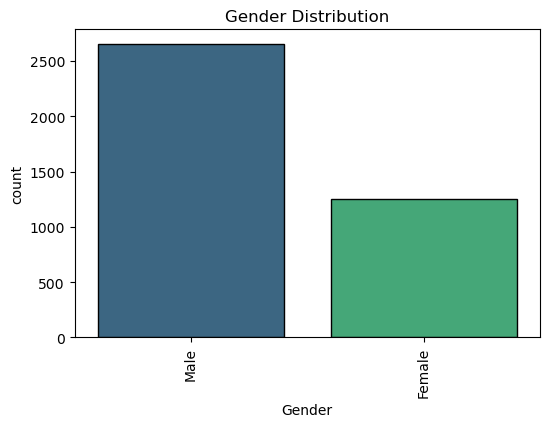

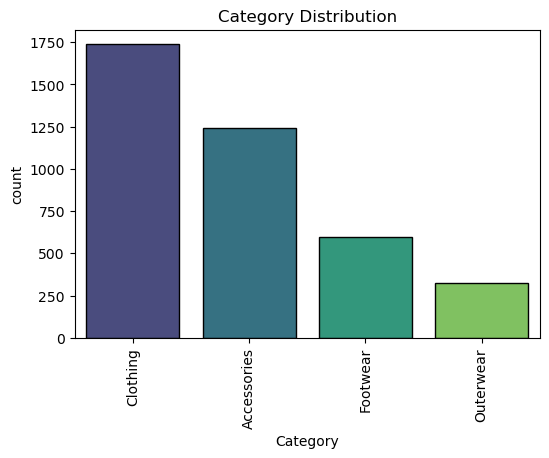

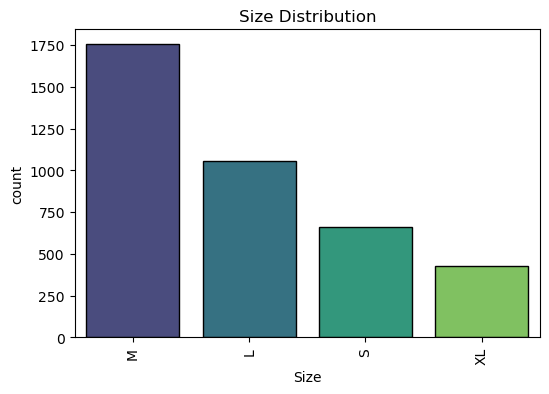

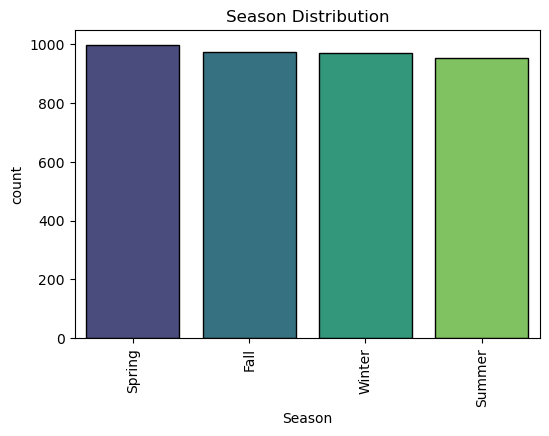

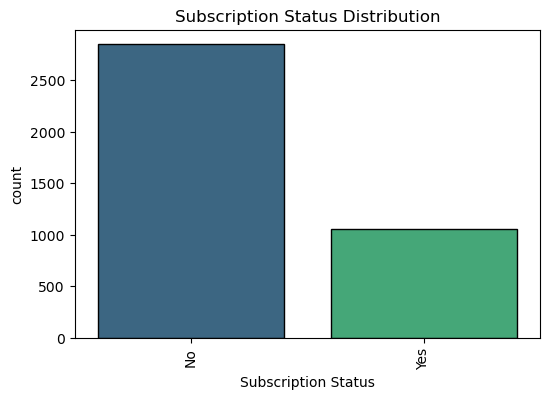

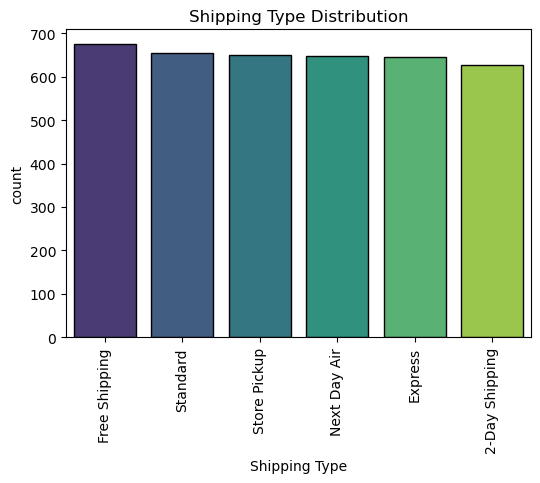

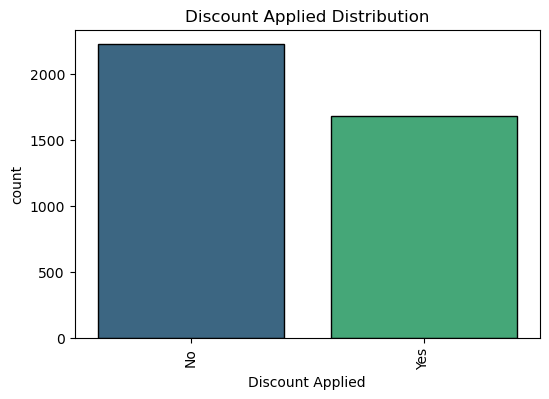

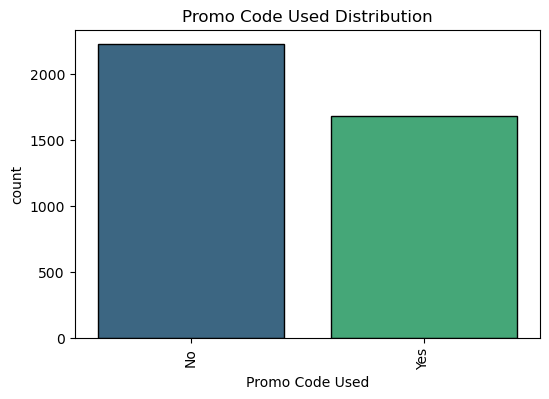

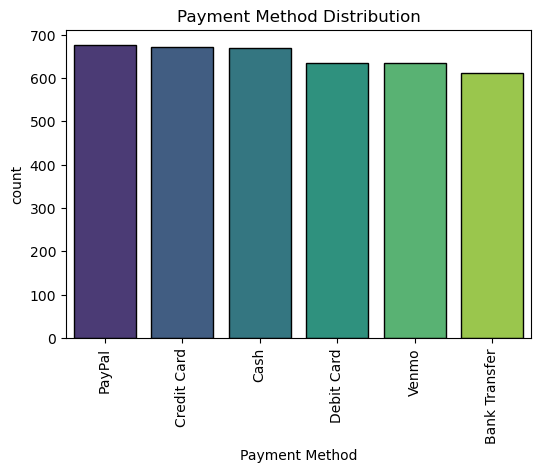

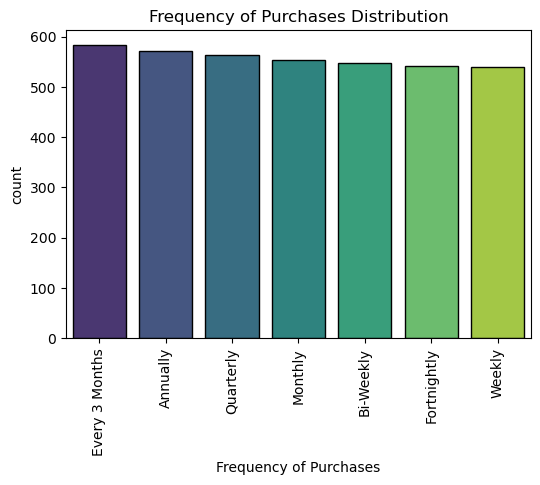

In [12]:
# Visualize distribution of categorical columns' unique values
for col in object_cols:
    if customer_data[col].nunique() <= 10:
        plt.figure(figsize=(6, 4))
        plt.xticks(rotation=90)
        sns.countplot(data=customer_data, x=col, palette='viridis', edgecolor='black', order=customer_data[col].value_counts().index)
        plt.title(f"{col} Distribution")

From the proportions and distibutions summaries, I've noticed some similarity in the `Discount Applied` and `Promo Code Used` columns. Could they be representing the same information?? Let's check!

In [13]:
#  Check if they are exactly the same (same order, same NaN positions)
exact_match = customer_data['Discount Applied'].equals(customer_data['Promo Code Used'])
print("Exact match:", exact_match)  # True if identical

Exact match: True


### NOTES:
- We have 13 categorical features in our data
- `Promo Code Used` and `Discount Applied` features represent the same information.

### ✅ Validation: Dropping  is Correct
 and  are perfectly identical across all 3,900 rows. Keeping both would introduce multicollinearity in any model and create redundant signals in segmentation logic. **Decision:** Retain  as the single source of truth for promotional behaviour. Drop  in the cleaning step.

## Understanding The Distribution of Numeric Columns

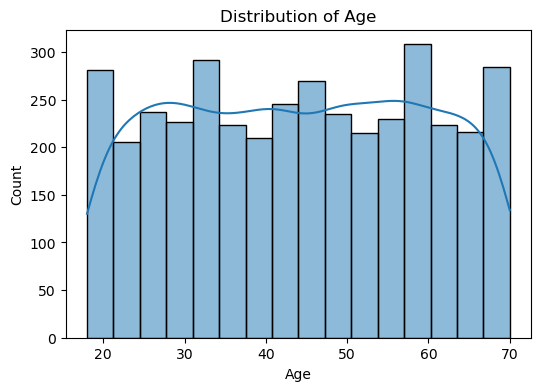

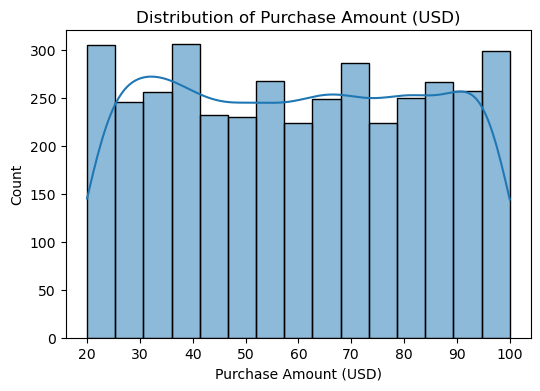

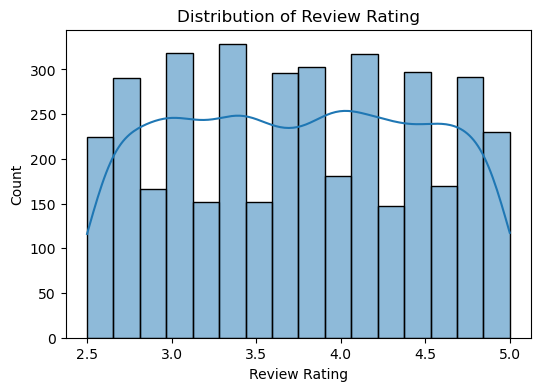

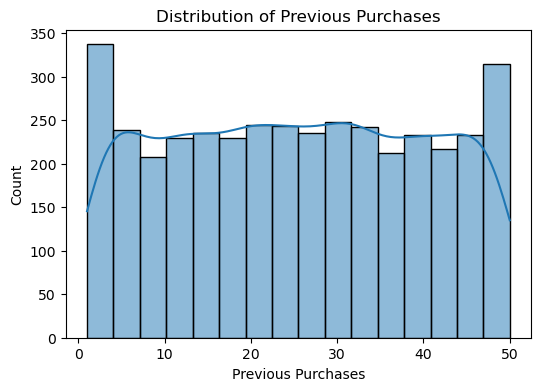

In [14]:
# Plot histograms for each numerical feature
num_cols = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]

for i, col in enumerate(num_cols):
    plt.figure(figsize=(6, 4))
    sns.histplot(customer_data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


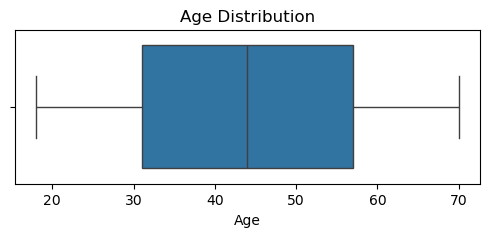

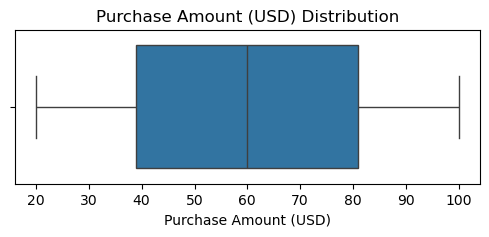

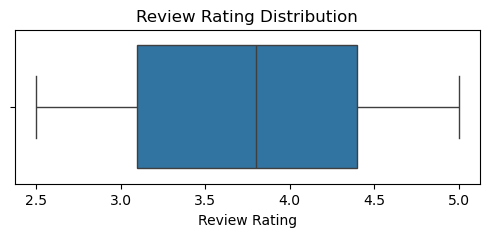

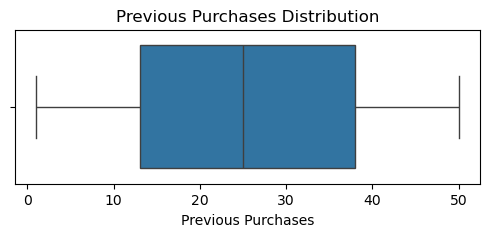

In [15]:
# Check for outliers in our data
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=customer_data[col])
    plt.title(f"{col} Distribution")
    plt.show()


In [16]:
customer_data[num_cols].skew().sort_values(ascending=False)


Purchase Amount (USD)    0.012702
Previous Purchases       0.003121
Review Rating            0.001355
Age                     -0.006380
dtype: float64

### NOTES:
- Numerical features do not show evidence of ouliers
- Skewness values are very close to zero so variables are symmetric. Very balanced distributions.

### ✅ Validation: Numeric Distributions Are Clean — No Aggressive Treatment Needed
All four numeric fields (, , , ) show near-symmetric distributions with skewness close to zero. Boxplots confirm no extreme outliers.

**Implications:**
- No log transformation needed for  before modelling
- No outlier removal or winsorizing required at this stage
-  ranges naturally (0–50+) and will be log-transformed *intentionally* later in feature engineering as a loyalty score proxy — not as a correction for skew, but as a deliberate design choice to model diminishing returns on loyalty

# DATA CLEANING
After profiling our data and identifying the data quality issues within our dataset, we'll go ahead and clean or data.
We will do the following:
1. Clean all column headers to follow a consistent format - all lowercase, no spaces before, between and after names, and underscores go between names.
2. Drop unnecessary columns. `size`, `color` are noisy. Also, we realized that `promo_code_used` feature represented similar information with the `discount_applied` feature. So we are going to drop it also.
3. Impute `review_rating` feature with the median for each category instead of the global median. We use the median since it is robust to outliers. The mean would also work fine because our data did not have any outliers as per our boxplots and skewness value was very close to zero.
4. Have a consistent naming for similar values for the `frequency_of_purchases` column. *'Fortnightly'* and *'Bi-Weekly'* represent the same period. *'Quarterly'* and *'Ever 3 months'* also represent the same period.

In [17]:
# Clean dataframe headers to follow a consistent format(lowercase, no spaces, and use of an underscore between names)
def clean_headers(df):
    df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
    return df
customer_data = clean_headers(customer_data)
customer_data = customer_data.rename(columns={'purchase_amount_(usd)': 'purchase_amount_usd'})
customer_data.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [18]:
# Drop unnecessary columns
customer_data = customer_data.drop(['color', 'size', 'promo_code_used'], axis=1)

In [19]:
# Impute missing values
customer_data["review_rating"] = customer_data.groupby("category")["review_rating"].transform(lambda x: x.fillna(x.median()))

In [20]:
consistent_mapping = {'Every 3 Months': 'Quarterly', 'Bi-Weekly': 'Fortnightly'}
customer_data["frequency_of_purchases"] = customer_data["frequency_of_purchases"].replace(consistent_mapping)
customer_data["frequency_of_purchases"].value_counts()

frequency_of_purchases
Quarterly      1147
Fortnightly    1089
Annually        572
Monthly         553
Weekly          539
Name: count, dtype: int64

### ✅ Validation: Frequency Label Standardisation
Two inconsistent labels were present:
-  → mapped to  ✅
-  → mapped to  ✅

This ensures the ordinal mapping in the feature engineering notebook () will work without silent mismatches. If left uncorrected,  would have mapped to  in the frequency score, silently degrading our loyalty and value calculations downstream.

In [21]:
customer_data.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually


# Save Clean data in a new csv

In [22]:
customer_data.to_csv(r"../data/cleaned/customer_data_clean.csv", index=False)